
# Heatwave, mobility, and physical activity: research-grade analysis

This notebook analyzes how participants' **mobility** (trip modes, distance, duration)
and **physical activity** (steps) change with **temperature**, with a focus on **heatwaves**.
It is designed for research use and includes:

- Data loading & cleaning
- Per-trip temperature assignment using the Open-Meteo API with caching
- Multiple heatwave definitions
- Daily participant-level panel construction
- Descriptive and dose–response analyses
- Regression and heatwave-effect models
- Machine learning models and feature importance
- Time-of-day and mode-specific patterns
- Spatial patterns by month and heatwave intensity
- Heterogeneity by age and gender
- Outlier and robustness checks


## Imports and configuration

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

DATA_DIR = Path("./data")


## Load core datasets


We assume the following files are available in `DATA_DIR`:

- `age.csv` — one row per participant with `participant_id`, `gender`, `yob`
- `steps.csv` — daily step counts (may contain multiple rows per participant/day)
- `all_movements_112.csv` — trip-level movements with times, modes, geohashes
- `all_paths_110.csv` — path points aggregated by time-of-day, day-of-week, month, geohash, mode

Some of the CSVs are **semicolon-delimited**, so we parse them accordingly.


In [9]:

age_path = DATA_DIR / "age.csv"
steps_path = DATA_DIR / "all_steps_2.csv"
movements_path = DATA_DIR / "all_movements_134.csv"
paths_path = DATA_DIR / "lokstadt_paths.csv"

age = pd.read_csv(age_path)

# Steps and movements/paths are semicolon-delimited in your sample
steps_raw = pd.read_csv(steps_path, sep=";")
movements_raw = pd.read_csv(movements_path, sep=";")
paths_raw = pd.read_csv(paths_path, sep=";")

age.head(), steps_raw.head(), movements_raw.head(), paths_raw.head()


(  participant_id gender   yob
 0        4T11G3A      F  1959
 1         1G2T1K      F  1976
 2        4B12HXW      F  1958
 3         5W2SXE      F  1959
 4         2E7B3M      M  1961,
   participant_id         day  steps
 0      219935XE1  2024-08-28   4179
 1      219935XE1  2024-08-28   3992
 2      219935XE1  2024-08-29   5254
 3      219935XE1  2024-08-29   3017
 4      219935XE1  2024-08-30   5837,
   participant_id                 start_time                   end_time start_geohash end_geohash  distance(m) mean_of_transport original_mean_of_transport  gCO2  is_power_saving
 0      1199121CX  2024-09-03 11:28:03+00:00  2024-09-03 11:30:07+00:00        u0m44x      u0m44x          518        ON_BICYCLE                 ON_BICYCLE     2            False
 1      1199121CX  2024-09-03 15:12:18+00:00  2024-09-03 15:17:23+00:00        u0m44x      u0m44x          359           WALKING                    WALKING     0            False
 2      1199121CX  2024-09-03 15:52:14+00:00  2024-09

## Basic cleaning and parsing


### Steps data

The `steps.csv` file has columns:

- `participant_id`
- `day` (date string)
- `steps`

There can be multiple entries per participant per day; we aggregate to one row per participant/day.


In [10]:

steps = steps_raw.copy()

# Handle the case where everything came in a single concatenated column
if steps.shape[1] == 1 and ";" in steps.columns[0]:
    steps = steps[steps.columns[0]].str.split(";", expand=True)
    steps.columns = ["participant_id", "day", "steps"]

steps["day"] = pd.to_datetime(steps["day"])
steps["steps"] = pd.to_numeric(steps["steps"], errors="coerce")

steps_daily = (
    steps
    .groupby(["participant_id", "day"], as_index=False)["steps"]
    .sum()
)

steps_daily.head()


,participant_id,day,steps
0,0H2T3S,2025-01-21,0
1,0H2T3S,2025-01-22,0
2,0H2T3S,2025-01-23,0
3,0H2T3S,2025-01-24,0
4,0H2T3S,2025-01-25,0



### Movement data

`all_movements_112.csv` contains trip-level movements with at least:

- `participant_id`
- `start_time`, `end_time` (timestamps)
- `start_geohash`, `end_geohash`
- `mean_of_transport`
- `gCO2`
- possibly distance

We parse timestamps and derive trip duration (minutes).


In [11]:

movements = movements_raw.copy()

# Handle potential single-column, semicolon-separated format
if movements.shape[1] == 1 and ";" in movements.columns[0]:
    header_cols = movements.columns[0].split(";")
    movements = movements[movements.columns[0]].str.split(";", expand=True)
    movements.columns = header_cols

# Parse timestamps
for col in ["start_time", "end_time"]:
    if col in movements.columns:
        movements[col] = pd.to_datetime(movements[col], errors="coerce")

# Precise timestamps and date-only
movements["start_time_precise"] = movements["start_time"]
movements["end_time_precise"] = movements["end_time"]
movements["start_date"] = movements["start_time_precise"].dt.date
movements["end_date"] = movements["end_time_precise"].dt.date

# Trip duration in minutes
if {"start_time_precise", "end_time_precise"}.issubset(movements.columns):
    movements["duration_min"] = (
        movements["end_time_precise"] - movements["start_time_precise"]
    ).dt.total_seconds() / 60.0

# Distance column (if available)
distance_col = None
for cand in ["distance(m)", "distance", "distance_m"]:
    if cand in movements.columns:
        distance_col = cand
        break

movements.head()


,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,start_time_precise,end_time_precise,start_date,end_date,duration_min
0,1199121CX,2024-09-03 11:28:03+00:00,2024-09-03 11:30:07+00:00,u0m44x,u0m44x,518,ON_BICYCLE,ON_BICYCLE,2,False,2024-09-03 11:28:03+00:00,2024-09-03 11:30:07+00:00,2024-09-03,2024-09-03,2.066667
1,1199121CX,2024-09-03 15:12:18+00:00,2024-09-03 15:17:23+00:00,u0m44x,u0m44x,359,WALKING,WALKING,0,False,2024-09-03 15:12:18+00:00,2024-09-03 15:17:23+00:00,2024-09-03,2024-09-03,5.083333
2,1199121CX,2024-09-03 15:52:14+00:00,2024-09-03 15:59:24+00:00,u0m44x,u0m468,416,WALKING,WALKING,0,False,2024-09-03 15:52:14+00:00,2024-09-03 15:59:24+00:00,2024-09-03,2024-09-03,7.166667
3,1199121CX,2024-09-03 15:59:25+00:00,2024-09-03 16:21:34+00:00,u0m468,u0m464,3091,ELECTRIC_BUS,ELECTRIC_BUS,197,False,2024-09-03 15:59:25+00:00,2024-09-03 16:21:34+00:00,2024-09-03,2024-09-03,22.150000
4,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,ON_BICYCLE,ON_BICYCLE,3,False,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,2024-09-03,2024-09-03,2.050000



### Path points data

`all_paths_110.csv` contains path points aggregated by:

- `time_range` (e.g. `6-9`, `18-21`)
- `day_of_week`
- `month`
- `mode_of_transport`
- `geohash`
- `direction`

We treat this as a spatial usage intensity table.


In [12]:

paths = paths_raw.copy()

if paths.shape[1] == 1 and ";" in paths.columns[0]:
    header_cols = paths.columns[0].split(";")
    paths = paths[paths.columns[0]].str.split(";", expand=True)
    paths.columns = header_cols

paths.head()


,time_range,day_of_week,month,mode_of_transport,geohash,direction
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST


## Temperature assignment via Open-Meteo + cache


We reuse your approach:

- Decode geohashes to lat/lon (with a cache)
- Query the **Open-Meteo historical API** for hourly temperatures
- Cache responses in `./data/temperature_cache.pkl`
- For each trip, compute **mean** and **max** temperature between start and end.

This section assumes that:

- `./data/temperature_cache.pkl` exists (possibly from your existing notebook), or
- It will be created and reused on subsequent runs.


In [14]:

import pickle as pkl
import requests
import time

# Optional geohash decoding lib (as in your original notebook)
try:
    import geolib.geohash as geolib
except ImportError:
    geolib = None

# Temperature cache
DATA_DIR_INTERNAL = Path("./data")
DATA_DIR_INTERNAL.mkdir(exist_ok=True)
temp_cache_path = DATA_DIR_INTERNAL / "temperature_cache.pkl"

try:
    temperature_cache = pkl.load(open(temp_cache_path, "rb"))
except FileNotFoundError:
    temperature_cache = {}

# Geohash -> coords cache
streamlit_dir = Path("./streamlit")
streamlit_dir.mkdir(exist_ok=True)
geohash_cache_path = streamlit_dir / "geohashes_to_coords.pkl"

try:
    geohashes_cache = pkl.load(open(geohash_cache_path, "rb"))
except FileNotFoundError:
    geohashes_cache = {}

def decode_geohash(geohash):
    """Decode geohash to (lat, lon), with on-disk cache."""
    global geohashes_cache

    if geohash in geohashes_cache:
        return geohashes_cache[geohash]

    if geolib is None:
        raise RuntimeError(
            "geolib is not available; cannot decode geohash. "
            "Install `geolib` or ensure geohashes_to_coords.pkl is populated."
        )

    lat, lon = geolib.decode(geohash)
    geohashes_cache[geohash] = (lat, lon)
    pkl.dump(geohashes_cache, open(geohash_cache_path, "wb"))
    return (lat, lon)

def get_temp(geohash, dt):
    """Query Open-Meteo historical weather API for a specific time.

    - Uses a daily (geohash, date) cache in `temperature_cache`
    - Extracts hourly temperature at the requested hour
    """
    url = "https://archive-api.open-meteo.com/v1/archive"

    date = dt.strftime("%Y-%m-%d")
    key = geohash + date

    if key in temperature_cache:
        data = temperature_cache[key]
    else:
        for _ in range(3):
            try:
                lat, lon = decode_geohash(geohash)
                params = {
                    "latitude": lat,
                    "longitude": lon,
                    "start_date": date,
                    "end_date": date,
                    "hourly": "temperature_2m",
                    "timezone": "UTC",
                }
                resp = requests.get(url, params=params, timeout=30)
                resp.raise_for_status()
                data = resp.json()
                temperature_cache[key] = data
                pkl.dump(temperature_cache, open(temp_cache_path, "wb"))
                break
            except requests.RequestException as e:
                print(f"Error fetching data for {geohash} {date}: {e}")
                pkl.dump(temperature_cache, open(temp_cache_path, "wb"))
                time.sleep(2)
        else:
            return None

    time_str = dt.strftime("%Y-%m-%dT%H:00")
    times = data.get("hourly", {}).get("time", [])
    temps = data.get("hourly", {}).get("temperature_2m", [])
    time_dict = dict(zip(times, temps))

    return time_dict.get(time_str, None)

def compute_trip_temps(row):
    """Compute mean and max temperature for a trip from start & end points."""
    if pd.isna(row.get("start_geohash")) or pd.isna(row.get("end_geohash")):
        return pd.Series({"mean_temp": np.nan, "max_temp": np.nan})

    try:
        t1 = get_temp(row["start_geohash"], row["start_time_precise"])
        t2 = get_temp(row["end_geohash"], row["end_time_precise"])
    except Exception as e:
        print(f"Error getting temps for row {row.name}: {e}")
        return pd.Series({"mean_temp": np.nan, "max_temp": np.nan})

    if t1 is None or t2 is None:
        return pd.Series({"mean_temp": np.nan, "max_temp": np.nan})

    return pd.Series({
        "mean_temp": (t1 + t2) / 2.0,
        "max_temp": max(t1, t2),
    })


EOFError: Ran out of input

In [7]:

# Attach per-trip temperatures (heavy the first time, then fast with cache)
movements[["mean_temp", "max_temp"]] = movements.apply(compute_trip_temps, axis=1)
movements[["participant_id", "start_time_precise", "end_time_precise",
           "start_geohash", "end_geohash", "mean_temp", "max_temp"]].head()


KeyboardInterrupt: 

## Daily temperature series and baseline heatwaves

In [10]:

# 2°C bins for trip-level mean/max temperature
bin_size = 2
min_mean = movements["mean_temp"].min()
max_mean = movements["mean_temp"].max()
max_max = movements["max_temp"].max()

mean_temp_bins = [-np.inf] + list(np.arange(0, int(max_mean) + bin_size + 1, bin_size))
max_temp_bins = [-np.inf] + list(np.arange(0, int(max_max) + bin_size + 1, bin_size))

movements["mean_temp_bin"] = pd.cut(movements["mean_temp"], bins=mean_temp_bins, right=True)
movements["max_temp_bin"] = pd.cut(movements["max_temp"], bins=max_temp_bins, right=True)

# Daily mean temperature series (study-wide)
movements["date"] = movements["start_time_precise"].dt.normalize()
temperature = (
    movements
    .dropna(subset=["mean_temp"])
    .groupby("date")["mean_temp"]
    .mean()
    .reset_index()
    .rename(columns={"mean_temp": "t_mean"})
)

# Classify temperature into bins (for daily aggregated analyses)
def classify_temp_bin(t):
    if pd.isna(t):
        return np.nan
    if t < 20:
        return "cool (<20°C)"
    if t < 25:
        return "warm (20–25°C)"
    if t < 30:
        return "hot (25–30°C)"
    if t < 35:
        return "very hot (30–35°C)"
    return "extreme (≥35°C)"

temperature = temperature.sort_values("date").reset_index(drop=True)
temperature["temp_bin"] = temperature["t_mean"].apply(classify_temp_bin)

# Baseline heatwave: 3+ consecutive days with t_mean >= 30°C
is_hot = temperature["t_mean"] >= 30
group_id = (is_hot != is_hot.shift(1)).cumsum()
temperature["heatwave_id"] = np.where(is_hot, group_id, np.nan)
hw_lengths = temperature.groupby("heatwave_id")["date"].transform("count")
temperature["is_heatwave_day"] = np.where(~temperature["heatwave_id"].isna() & (hw_lengths >= 3), True, False)

temperature.head(10)


,date,t_mean,temp_bin,heatwave_id,is_heatwave_day
0,2024-08-28 00:00:00+00:00,20.332353,warm (20–25°C),NaN,False
1,2024-08-29 00:00:00+00:00,24.666667,warm (20–25°C),NaN,False
2,2024-08-30 00:00:00+00:00,25.320000,hot (25–30°C),NaN,False
3,2024-08-31 00:00:00+00:00,25.110000,hot (25–30°C),NaN,False
4,2024-09-01 00:00:00+00:00,25.885000,hot (25–30°C),NaN,False
5,2024-09-02 00:00:00+00:00,20.847917,warm (20–25°C),NaN,False
6,2024-09-03 00:00:00+00:00,22.077778,warm (20–25°C),NaN,False
7,2024-09-04 00:00:00+00:00,20.039474,warm (20–25°C),NaN,False
8,2024-09-05 00:00:00+00:00,20.685714,warm (20–25°C),NaN,False
9,2024-09-06 00:00:00+00:00,22.319444,warm (20–25°C),NaN,False



## Multiple heatwave definitions

We add several alternative definitions to allow robustness checks:

- **HW1 (30C_3d)**: ≥30°C for at least 3 consecutive days
- **HW2 (q90_3d)**: ≥90th percentile of `t_mean` for at least 3 consecutive days
- **HW3 (q95_2d)**: ≥95th percentile of `t_mean` for at least 2 consecutive days


In [11]:

temperature = temperature.sort_values("date").reset_index(drop=True)
temperature = temperature.rename(columns={"is_heatwave_day": "is_hw_30C_3d"})

def mark_heatwaves(temp_df, threshold, min_run):
    temp_df = temp_df.sort_values("date").reset_index(drop=True)
    hot = temp_df["t_mean"] >= threshold
    group_id = (hot != hot.shift(1)).cumsum()
    hw_id = group_id.where(hot, other=pd.NA)
    run_lengths = temp_df.groupby(hw_id)["date"].transform("count")
    return (hot & (run_lengths >= min_run)).fillna(False)

q90 = temperature["t_mean"].quantile(0.90)
q95 = temperature["t_mean"].quantile(0.95)

temperature["is_hw_30C_3d"] = temperature["is_hw_30C_3d"].fillna(False)
temperature["is_hw_q90_3d"] = mark_heatwaves(temperature, threshold=q90, min_run=3)
temperature["is_hw_q95_2d"] = mark_heatwaves(temperature, threshold=q95, min_run=2)

temperature["month"] = temperature["date"].dt.month
hw_intensity_by_month = (
    temperature
    .groupby("month")[["is_hw_30C_3d", "is_hw_q90_3d", "is_hw_q95_2d"]]
    .mean()
    .rename(columns=lambda c: c + "_share")
)

hw_intensity_by_month


,is_hw_30C_3d_share,is_hw_q90_3d_share,is_hw_q95_2d_share
month,,,
1,0.0,0.000000,0.000000
2,0.0,0.000000,0.000000
3,0.0,0.000000,0.000000
4,0.0,0.000000,0.000000
5,0.0,0.064516,0.000000
6,0.0,0.600000,0.233333
7,0.0,0.290323,0.096774
8,0.0,0.428571,0.285714
9,0.0,0.016667,0.016667


## Daily participant-level panel


We now construct a **daily panel** with one row per `(participant_id, date)` containing:

- Steps
- Travel time and emissions
- Distance (if available)
- Temperature, temperature bins, and heatwave flags
- Calendar variables (weekday, month)


In [12]:

# Steps side
steps_daily = steps_daily.rename(columns={"day": "date"})
steps_daily["date"] = steps_daily["date"].dt.tz_localize('UTC').dt.normalize()

temp_cols = ["date", "t_mean", "temp_bin", "is_hw_30C_3d", "is_hw_q90_3d", "is_hw_q95_2d"]
temp_cols = [c for c in temp_cols if c in temperature.columns]

steps_panel = steps_daily.merge(temperature[temp_cols], on="date", how="left")

# Movements daily summary
movements_daily = movements.copy()
movements_daily["date"] = movements_daily["start_time_precise"].dt.normalize()

agg_dict = {}
if "duration_min" in movements_daily.columns:
    agg_dict["duration_min"] = "sum"
if "gCO2" in movements_daily.columns:
    agg_dict["gCO2"] = "sum"
if distance_col is not None:
    agg_dict[distance_col] = "sum"

movements_daily_summary = (
    movements_daily
    .groupby(["participant_id", "date"], as_index=False)
    .agg(agg_dict)
)

movements_panel = movements_daily_summary.merge(temperature[temp_cols], on="date", how="left")

In [13]:
# Merge into single panel
temp_cols = [c for c in temp_cols if c != "date"]

day_panel = steps_panel.merge(
    movements_panel.drop(columns=temp_cols, errors="ignore"),
    on=["participant_id", "date"],
    how="outer",
    suffixes=("", "_mov")
)

day_panel["weekday"] = day_panel["date"].dt.dayofweek
day_panel["month"] = day_panel["date"].dt.month

day_panel.head()


,participant_id,date,steps,t_mean,temp_bin,is_hw_30C_3d,is_hw_q90_3d,is_hw_q95_2d,duration_min,gCO2,distance(m),weekday,month
0,0H2T3S,2025-01-21 00:00:00+00:00,0.0,-0.578431,cool (<20°C),False,False,False,NaN,NaN,NaN,1,1
1,0H2T3S,2025-01-22 00:00:00+00:00,0.0,1.072581,cool (<20°C),False,False,False,NaN,NaN,NaN,2,1
2,0H2T3S,2025-01-23 00:00:00+00:00,0.0,4.017460,cool (<20°C),False,False,False,NaN,NaN,NaN,3,1
3,0H2T3S,2025-01-24 00:00:00+00:00,0.0,5.552941,cool (<20°C),False,False,False,NaN,NaN,NaN,4,1
4,0H2T3S,2025-01-25 00:00:00+00:00,0.0,8.854255,cool (<20°C),False,False,False,NaN,NaN,NaN,5,1


### Trips per mode per day

In [14]:

# Per-day mode counts (for mode share by temperature)
if "mean_of_transport" in movements.columns:
    trips_per_mode = (
        movements
        .groupby(["participant_id", "date", "mean_of_transport"], as_index=False)
        .size()
        .rename(columns={"size": "n_trips"})
    )
else:
    trips_per_mode = pd.DataFrame()

trips_per_mode.head()


,participant_id,date,mean_of_transport,n_trips
0,0H2T3S,2025-01-28 00:00:00+00:00,BUS,1
1,0H2T3S,2025-01-28 00:00:00+00:00,TRAIN,1
2,0H2T3S,2025-01-28 00:00:00+00:00,WALKING,2
3,0L3S1J,2025-05-23 00:00:00+00:00,BUS,1
4,0L3S1J,2025-05-23 00:00:00+00:00,TRAIN,4


## Demographics (age, gender)

In [15]:

# Compute age at a reference year (e.g. median year in the dataset)
ref_year = day_panel["date"].dt.year.median() if not day_panel.empty else 2024
age["age"] = ref_year - age["yob"]

panel_demo = day_panel.merge(age[["participant_id", "gender", "age"]],
                             on="participant_id", how="left")

panel_demo.head()


,participant_id,date,steps,t_mean,temp_bin,is_hw_30C_3d,is_hw_q90_3d,is_hw_q95_2d,duration_min,gCO2,distance(m),weekday,month,gender,age
0,0H2T3S,2025-01-21 00:00:00+00:00,0.0,-0.578431,cool (<20°C),False,False,False,NaN,NaN,NaN,1,1,NaN,NaN
1,0H2T3S,2025-01-22 00:00:00+00:00,0.0,1.072581,cool (<20°C),False,False,False,NaN,NaN,NaN,2,1,NaN,NaN
2,0H2T3S,2025-01-23 00:00:00+00:00,0.0,4.017460,cool (<20°C),False,False,False,NaN,NaN,NaN,3,1,NaN,NaN
3,0H2T3S,2025-01-24 00:00:00+00:00,0.0,5.552941,cool (<20°C),False,False,False,NaN,NaN,NaN,4,1,NaN,NaN
4,0H2T3S,2025-01-25 00:00:00+00:00,0.0,8.854255,cool (<20°C),False,False,False,NaN,NaN,NaN,5,1,NaN,NaN


## Descriptive patterns: steps and mobility vs temperature

In [16]:

steps_by_bin = (
    panel_demo
    .dropna(subset=["temp_bin", "steps"])
    .groupby("temp_bin")["steps"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
steps_by_bin


,count,mean,median,std
temp_bin,,,,
cool (<20°C),11101,6106.778038,5363.0,5024.757902
hot (25–30°C),775,6674.150968,5775.0,5149.571767
warm (20–25°C),2125,6586.808471,5571.0,5535.085623


<Figure size 640x480 with 0 Axes>

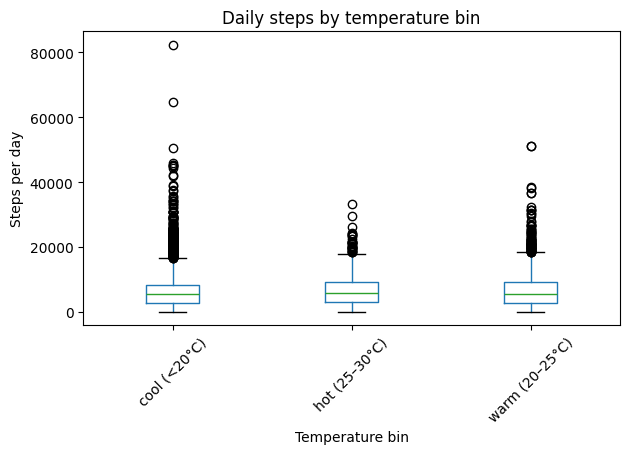

In [17]:

plt.figure()
panel_demo.dropna(subset=["temp_bin", "steps"]).boxplot(
    column="steps", by="temp_bin", vert=True, grid=False
)
plt.suptitle("")
plt.title("Daily steps by temperature bin")
plt.xlabel("Temperature bin")
plt.ylabel("Steps per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:

if "duration_min" in panel_demo.columns:
    travel_by_bin = (
        panel_demo
        .dropna(subset=["temp_bin", "duration_min"])
        .groupby("temp_bin")["duration_min"]
        .agg(["count", "mean", "median", "std"])
        .sort_index()
    )
    travel_by_bin


<Figure size 640x480 with 0 Axes>

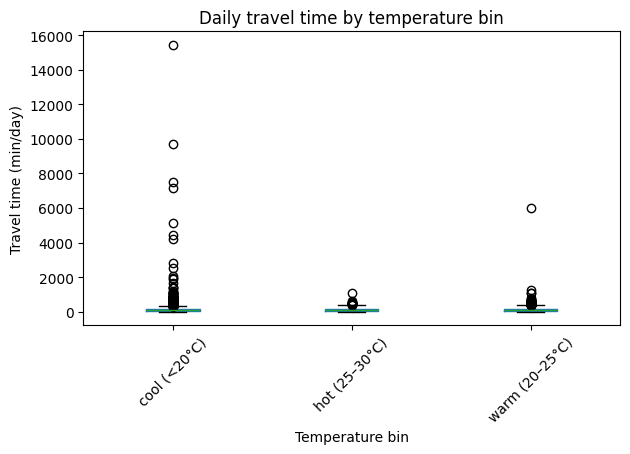

In [19]:

if "duration_min" in panel_demo.columns:
    plt.figure()
    panel_demo.dropna(subset=["temp_bin", "duration_min"]).boxplot(
        column="duration_min", by="temp_bin", vert=True, grid=False
    )
    plt.suptitle("")
    plt.title("Daily travel time by temperature bin")
    plt.xlabel("Temperature bin")
    plt.ylabel("Travel time (min/day)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Heatwave vs non-heatwave days

In [20]:

if "is_hw_30C_3d" in panel_demo.columns:
    panel_demo["hw_flag_30C_3d"] = np.where(panel_demo["is_hw_30C_3d"], "heatwave", "non-heatwave")

    steps_hw = (
        panel_demo
        .dropna(subset=["steps", "hw_flag_30C_3d"])
        .groupby("hw_flag_30C_3d")["steps"]
        .agg(["count", "mean", "median", "std"])
    )
    steps_hw


In [21]:

if "is_hw_q90_3d" in panel_demo.columns:
    panel_demo["hw_flag_q90"] = np.where(panel_demo["is_hw_q90_3d"], "heatwave_q90", "non-heatwave_q90")
    steps_hw_q90 = (
        panel_demo
        .dropna(subset=["steps", "hw_flag_q90"])
        .groupby("hw_flag_q90")["steps"]
        .agg(["count", "mean", "median", "std"])
    )
    steps_hw_q90


## Dose–response relationships

In [22]:
panel_dr = panel_demo.dropna(subset=["t_mean", "steps"]).copy()
panel_dr["t_mean_round"] = panel_dr["t_mean"].round(0)

dose_steps = (
    panel_dr
    .groupby("t_mean_round")["steps"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("t_mean_round")
)

dose_travel = None
if "duration_min" in panel_dr.columns:
    dose_travel = (
        panel_dr
        .groupby("t_mean_round")["duration_min"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("t_mean_round")
    )

dose_steps.head(), dose_travel.head() if dose_travel is not None else None


(   t_mean_round  count         mean  median
 0          -7.0     17  5328.764706  4650.0
 1          -6.0     16  6359.750000  6189.0
 2          -3.0    112  6743.750000  5821.0
 3          -2.0     73  5844.958904  5169.0
 4          -1.0    187  6434.844920  6105.0,
    t_mean_round  count        mean      median
 0          -7.0      4  114.762500  106.066667
 1          -6.0      9  165.950000  105.500000
 2          -3.0     50   98.245333   67.208333
 3          -2.0     34  399.613725   78.916667
 4          -1.0     82  112.435772   77.900000)

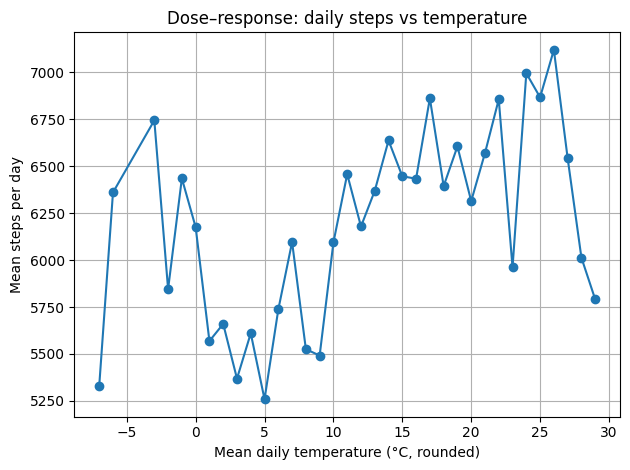

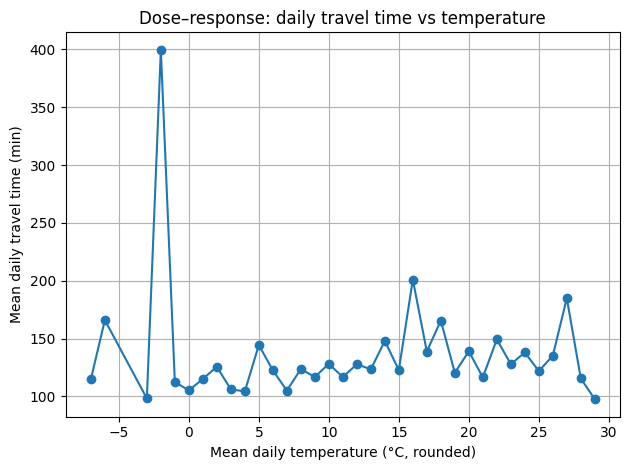

In [23]:

plt.figure()
plt.plot(dose_steps["t_mean_round"], dose_steps["mean"], marker="o")
plt.xlabel("Mean daily temperature (°C, rounded)")
plt.ylabel("Mean steps per day")
plt.title("Dose–response: daily steps vs temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

if dose_travel is not None:
    plt.figure()
    plt.plot(dose_travel["t_mean_round"], dose_travel["mean"], marker="o")
    plt.xlabel("Mean daily temperature (°C, rounded)")
    plt.ylabel("Mean daily travel time (min)")
    plt.title("Dose–response: daily travel time vs temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Regression models for steps and mobility

In [24]:

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    sm = None
    smf = None
    print("statsmodels is not installed; install it to run regression models.")


In [25]:

if smf is not None:
    reg = panel_demo.dropna(subset=["steps", "t_mean"]).copy()
    reg["log_steps"] = np.log1p(reg["steps"])

    formula1 = "log_steps ~ t_mean + I(t_mean**2) + C(weekday) + C(month)"
    model1 = smf.ols(formula=formula1, data=reg).fit()
    print("Model 1: log(steps) ~ temp + temp^2 + weekday + month")
    print(model1.summary())


Model 1: log(steps) ~ temp + temp^2 + weekday + month
                            OLS Regression Results                            
Dep. Variable:              log_steps   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     16.53
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           1.23e-54
Time:                        22:12:26   Log-Likelihood:                -30762.
No. Observations:               14001   AIC:                         6.156e+04
Df Residuals:                   13981   BIC:                         6.172e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [28]:

if smf is not None and "duration_min" in panel_demo.columns:
    reg2 = panel_demo.dropna(subset=["duration_min", "t_mean"]).copy()
    reg2["log_duration"] = np.log1p(reg2["duration_min"])

    formula2 = "log_duration ~ t_mean + I(t_mean**2) + C(weekday) + C(month)"
    model2 = smf.ols(formula=formula2, data=reg2).fit()
    print("Model 2: log(travel time) ~ temp + temp^2 + weekday + month")
    print(model2.summary())


Model 2: log(travel time) ~ temp + temp^2 + weekday + month
                            OLS Regression Results                            
Dep. Variable:           log_duration   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     8.564
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           1.60e-24
Time:                        22:17:00   Log-Likelihood:                -10078.
No. Observations:                6923   AIC:                         2.020e+04
Df Residuals:                    6903   BIC:                         2.033e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [27]:

# Participant fixed-effects via dummies (can be heavy if many participants)
if smf is not None:
    reg_fe = reg.copy()
    # Optionally subsample if extremely large
    # reg_fe = reg_fe.sample(min(50000, len(reg_fe)), random_state=0)

    formula_fe = "log_steps ~ t_mean + I(t_mean**2) + C(weekday) + C(participant_id)"
    model_fe = smf.ols(formula=formula_fe, data=reg_fe).fit()
    print("Model FE: log(steps) ~ temp + temp^2 + weekday + participant FE")
    print(model_fe.summary())


Model FE: log(steps) ~ temp + temp^2 + weekday + participant FE
                            OLS Regression Results                            
Dep. Variable:              log_steps   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     73.36
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:14:29   Log-Likelihood:                -27210.
No. Observations:               14001   AIC:                         5.469e+04
Df Residuals:                   13868   BIC:                         5.569e+04
Df Model:                         132                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

In [29]:

# Heatwave-focused model
if smf is not None and "is_hw_30C_3d" in panel_demo.columns:
    reg_hw = panel_demo.dropna(subset=["steps", "t_mean"]).copy()
    reg_hw["log_steps"] = np.log1p(reg_hw["steps"])
    formula_hw = "log_steps ~ t_mean + is_hw_30C_3d + C(weekday) + C(month)"
    model_hw = smf.ols(formula=formula_hw, data=reg_hw).fit()
    print("Model HW: log(steps) ~ temp + heatwave(30C,3d) + weekday + month")
    print(model_hw.summary())


Model HW: log(steps) ~ temp + heatwave(30C,3d) + weekday + month
                            OLS Regression Results                            
Dep. Variable:              log_steps   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     17.02
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           1.07e-53
Time:                        22:17:22   Log-Likelihood:                -30766.
No. Observations:               14001   AIC:                         6.157e+04
Df Residuals:                   13982   BIC:                         6.171e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

## Machine learning: prediction and feature importance

In [30]:

try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
except ImportError:
    RandomForestRegressor = None
    print("scikit-learn is not installed; install it to run ML models.")


Random forest R^2 train: 0.139, test: -0.079
Feature importances (steps model):
t_mean          0.547870
month           0.146089
weekday         0.132356
age_filled      0.109895
gender_male     0.044628
is_hw_q90_3d    0.012172
is_hw_q95_2d    0.006991
is_hw_30C_3d    0.000000
dtype: float64


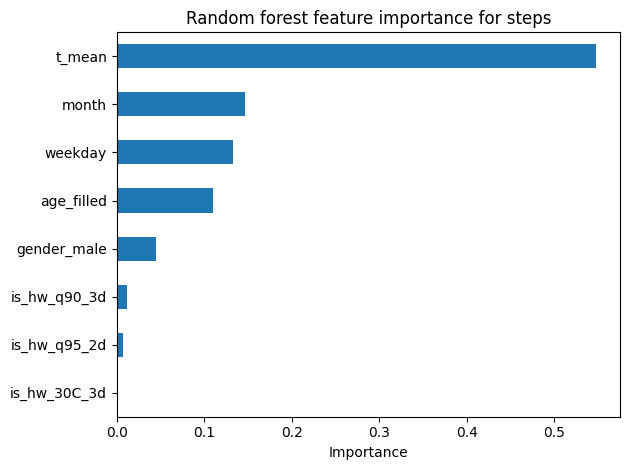

In [31]:

if RandomForestRegressor is not None:
    ml = panel_demo.dropna(subset=["steps", "t_mean"]).copy()
    ml["gender_male"] = (ml["gender"] == "M").astype(int)
    ml["age_filled"] = ml["age"].fillna(ml["age"].median())

    feature_cols = ["t_mean", "weekday", "month", "age_filled", "gender_male"]
    for col in ["is_hw_30C_3d", "is_hw_q90_3d", "is_hw_q95_2d"]:
        if col in ml.columns:
            feature_cols.append(col)

    X = ml[feature_cols]
    y = ml["steps"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
    rf.fit(X_train, y_train)

    r2_train = rf.score(X_train, y_train)
    r2_test = rf.score(X_test, y_test)
    print(f"Random forest R^2 train: {r2_train:.3f}, test: {r2_test:.3f}")

    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("Feature importances (steps model):")
    print(importances)

    plt.figure()
    importances[::-1].plot(kind="barh")
    plt.xlabel("Importance")
    plt.title("Random forest feature importance for steps")
    plt.tight_layout()
    plt.show()


## Time-of-day and mode-specific responses

In [32]:

mov_td = movements.dropna(subset=["start_time_precise", "mean_temp"]).copy()
mov_td["start_hour"] = mov_td["start_time_precise"].dt.hour
mov_td["mean_temp_bin_2C"] = pd.cut(mov_td["mean_temp"], bins=np.arange(-10, 45, 2))

if "mean_of_transport" in mov_td.columns:
    td_counts = (
        mov_td
        .groupby(["start_hour", "mean_temp_bin_2C", "mean_of_transport"], as_index=False)
        .size()
        .rename(columns={"size": "n_trips"})
    )
else:
    td_counts = (
        mov_td
        .groupby(["start_hour", "mean_temp_bin_2C"], as_index=False)
        .size()
        .rename(columns={"size": "n_trips"})
    )

td_counts.head()


/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_25674/3521907477.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["start_hour", "mean_temp_bin_2C", "mean_of_transport"], as_index=False)


,start_hour,mean_temp_bin_2C,mean_of_transport,n_trips
0,0,"(-10, -8]",BOAT,0
1,0,"(-10, -8]",BOAT_NO_ENGINE,0
2,0,"(-10, -8]",BUS,0
3,0,"(-10, -8]",CAR,0
4,0,"(-10, -8]",COACH,0


/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_25674/3026777287.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["start_hour", "temp_cat"], as_index=False)


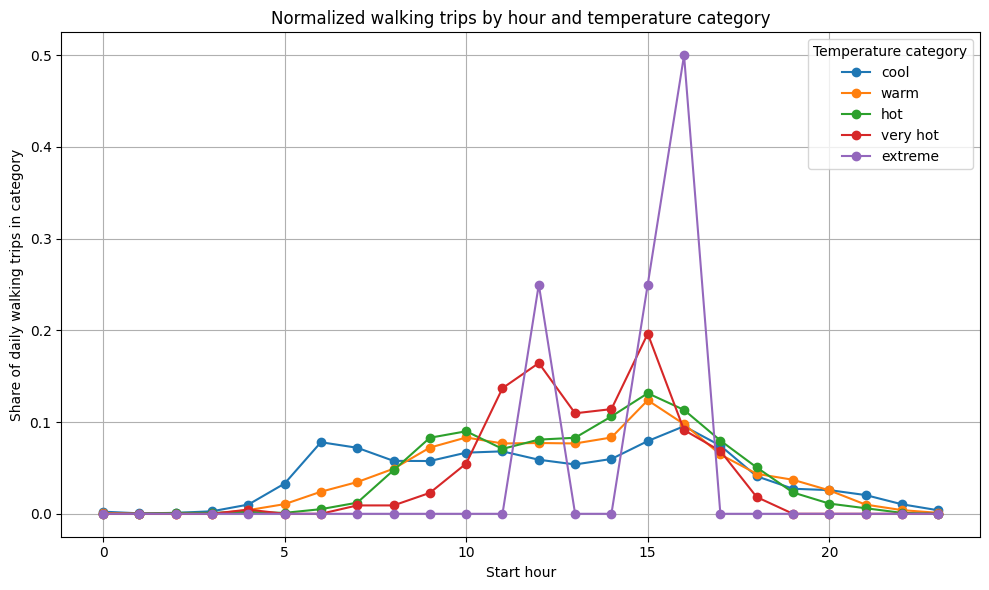

In [ ]:
# Example: walking trips per hour by temperature category (normalized by trip counts)

if "mean_of_transport" in mov_td.columns:
    # 1) Select walking modes
    mot_walk = ["WALKING"]
    subset = mov_td[mov_td["mean_of_transport"].isin(mot_walk)].copy()

    # 2) Temperature categories based on trip-level temperature
    subset["temp_cat"] = pd.cut(
        subset["mean_temp"],
        bins=[-50, 20, 25, 30, 100],
        labels=["<20", "20-25", "25-30", ">30"]
    )

    # 3) Count walking trips per hour per category
    walks_hour_temp = (
        subset
        .groupby(["start_hour", "temp_cat"], as_index=False)
        .size()
        .rename(columns={"size": "n_trips"})
    )

    # 4) Count total number of walking trips IN EACH TEMP CATEGORY
    #    (so categories with few observations still appear correctly)
    trip_counts = subset["temp_cat"].value_counts().to_dict()
    
    # Map category -> total trips (convert to numeric)
    walks_hour_temp["trips_in_cat"] = walks_hour_temp["temp_cat"].map(trip_counts).astype(int)

    # 5) Normalize: compute the share of trips happening at each hour for each category
    walks_hour_temp["share_within_cat"] = (
        walks_hour_temp["n_trips"] / walks_hour_temp["trips_in_cat"]
    )

    # 6) Plot normalized curves
    plt.figure(figsize=(10,6))
    for cat in walks_hour_temp["temp_cat"].dropna().unique():
        df_cat = walks_hour_temp[walks_hour_temp["temp_cat"] == cat]
        plt.plot(
            df_cat["start_hour"],
            df_cat["share_within_cat"],
            marker="o",
            label=str(cat)
        )

    plt.xlabel("Start hour")
    plt.ylabel("Share of daily walking trips in category")
    plt.title("Normalized walking trips by hour and temperature category")
    plt.legend(title="Temperature category")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [34]:
# remove outliers: walking trips longer than 15 km:
mov_td = mov_td[mov_td["distance(m)"] <= 15000].copy()

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_25674/1959146244.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["start_hour", "temp_cat"], as_index=False)[distance_col]


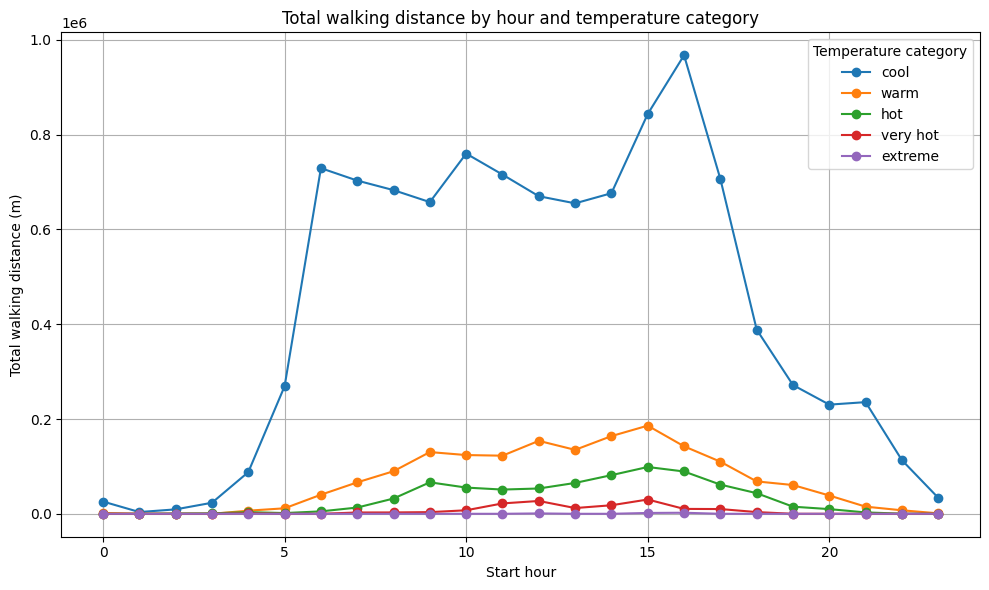

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_25674/1959146244.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["start_hour", "temp_cat"], as_index=False)[distance_col]


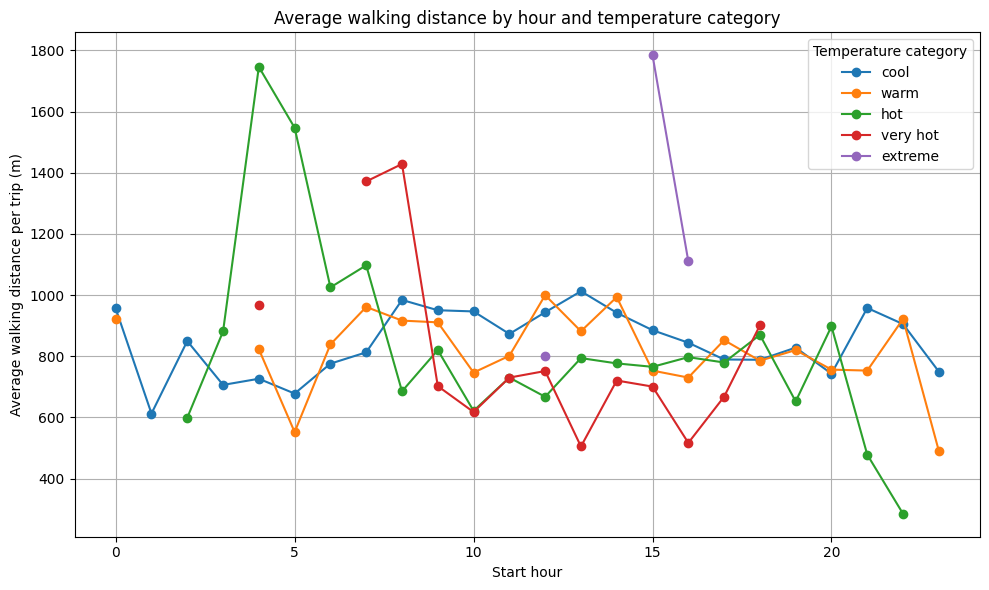

In [35]:
# Example: walking trips per hour by temperature category (normalized by trip counts)

if "mean_of_transport" in mov_td.columns and distance_col is not None:
    # 1) Select walking modes
    mot_walk = ["WALKING"]
    subset = mov_td[mov_td["mean_of_transport"].isin(mot_walk)].copy()
    
    # Convert distance to numeric
    subset[distance_col] = pd.to_numeric(subset[distance_col], errors='coerce')

    # 2) Temperature categories based on trip-level temperature
    subset["temp_cat"] = pd.cut(
        subset["mean_temp"],
        bins=[-50, 20, 25, 30, 35, 100],
        labels=["cool", "warm", "hot", "very hot", "extreme"]
    )

    # 3) Sum total distance for walking trips per hour per category
    walks_hour_temp = (
        subset
        .groupby(["start_hour", "temp_cat"], as_index=False)[distance_col]
        .sum()
        .rename(columns={distance_col: "total_distance"})
    )

    # 4) Plot total distance per hour by temperature category
    plt.figure(figsize=(10,6))
    for cat in walks_hour_temp["temp_cat"].dropna().unique():
        df_cat = walks_hour_temp[walks_hour_temp["temp_cat"] == cat]
        plt.plot(
            df_cat["start_hour"],
            df_cat["total_distance"],
            marker="o",
            label=str(cat)
        )

    plt.xlabel("Start hour")
    plt.ylabel("Total walking distance (m)")
    plt.title("Total walking distance by hour and temperature category")
    plt.legend(title="Temperature category")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Alternative: Average distance per trip
    walks_hour_temp_avg = (
        subset
        .groupby(["start_hour", "temp_cat"], as_index=False)[distance_col]
        .mean()
        .rename(columns={distance_col: "avg_distance"})
    )

    plt.figure(figsize=(10,6))
    for cat in walks_hour_temp_avg["temp_cat"].dropna().unique():
        df_cat = walks_hour_temp_avg[walks_hour_temp_avg["temp_cat"] == cat]
        plt.plot(
            df_cat["start_hour"],
            df_cat["avg_distance"],
            marker="o",
            label=str(cat)
        )

    plt.xlabel("Start hour")
    plt.ylabel("Average walking distance per trip (m)")
    plt.title("Average walking distance by hour and temperature category")
    plt.legend(title="Temperature category")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Spatial patterns and heatwave intensity

In [36]:

paths_spatial = paths.copy()
paths_spatial["month"] = pd.to_numeric(paths_spatial["month"], errors="coerce")

paths_month_mode = (
    paths_spatial
    .groupby(["month", "mode_of_transport"], as_index=False)
    .size()
    .rename(columns={"size": "n_points"})
)

paths_month_mode = paths_month_mode.merge(
    hw_intensity_by_month.reset_index(),
    on="month",
    how="left"
)

paths_month_mode.head()


,month,mode_of_transport,n_points,is_hw_30C_3d_share,is_hw_q90_3d_share,is_hw_q95_2d_share
0,1,BUS,4190,0.0,0.0,0.0
1,1,CAR,24606,0.0,0.0,0.0
2,1,ON_BICYCLE,6372,0.0,0.0,0.0
3,1,TRAIN,16930,0.0,0.0,0.0
4,1,TRAM,308,0.0,0.0,0.0


        hw_group mode_of_transport  share_within_month
0  high-heatwave              BOAT            0.002159
1  high-heatwave               BUS            0.055368
2  high-heatwave               CAR            0.474369
3  high-heatwave        ON_BICYCLE            0.098471
4  high-heatwave             PLANE            0.000599
5  high-heatwave             TRAIN            0.260665
6  high-heatwave              TRAM            0.007136
7  high-heatwave           WALKING            0.102323


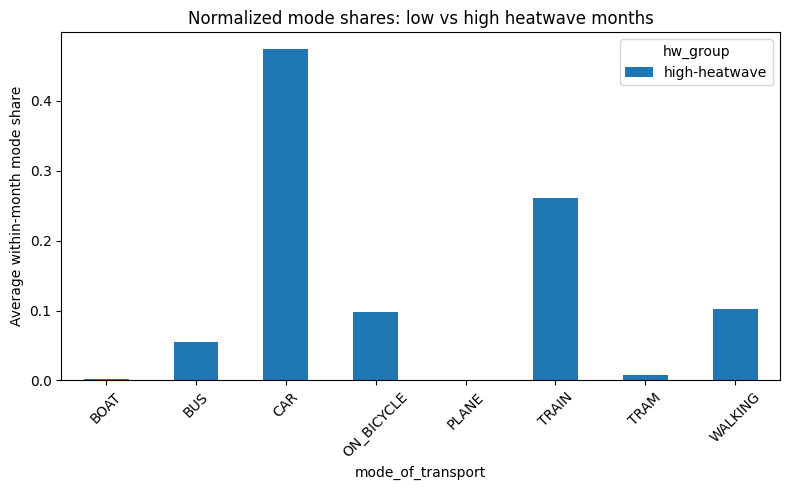

In [37]:
# --- Corrected & normalized heatwave mode-share analysis ---

# 1. Compute within-month mode share
#    Each month contributes equally, avoiding bias from number of observations.
paths_month_mode["share_within_month"] = (
    paths_month_mode["n_points"] /
    paths_month_mode.groupby("month")["n_points"].transform("sum")
)

# 2. Classify months into low-heatwave vs high-heatwave
#    based on median heatwave intensity.
median_hw = hw_intensity_by_month["is_hw_30C_3d_share"].median()

# Merge heatwave intensity per month (if not already merged)
if "is_hw_30C_3d_share" not in paths_month_mode.columns:
    paths_month_mode = paths_month_mode.merge(
        hw_intensity_by_month[["is_hw_30C_3d_share"]],
        on="month",
        how="left"
    )

paths_month_mode["hw_group"] = np.where(
    paths_month_mode["is_hw_30C_3d_share"] >= median_hw,
    "high-heatwave",
    "low-heatwave"
)

# 3. Average share across months within each group
mode_share_hw = (
    paths_month_mode
    .groupby(["hw_group", "mode_of_transport"])["share_within_month"]
    .mean()
    .reset_index()
)

print(mode_share_hw)

# 4. Plot properly normalized mode shares
pivot = mode_share_hw.pivot(
    index="mode_of_transport",
    columns="hw_group",
    values="share_within_month"
)

pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Average within-month mode share")
plt.title("Normalized mode shares: low vs high heatwave months")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Heterogeneity by age and gender

In [38]:

bins = [0, 30, 45, 60, 120]
labels = ["<30", "30–45", "45–60", "60+"]
panel_demo["age_group"] = pd.cut(panel_demo["age"], bins=bins, labels=labels, right=False)

steps_age_temp = (
    panel_demo
    .dropna(subset=["temp_bin", "age_group", "steps"])
    .groupby(["age_group", "temp_bin"])["steps"]
    .mean()
    .unstack("temp_bin")
)

steps_age_temp


/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_25674/4013870751.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "temp_bin"])["steps"]


temp_bin,cool (<20°C),hot (25–30°C),warm (20–25°C)
age_group,,,
<30,NaN,NaN,NaN
30–45,NaN,NaN,NaN
45–60,9609.171053,8854.294118,9108.267857
60+,6136.682432,5458.848101,5947.392344


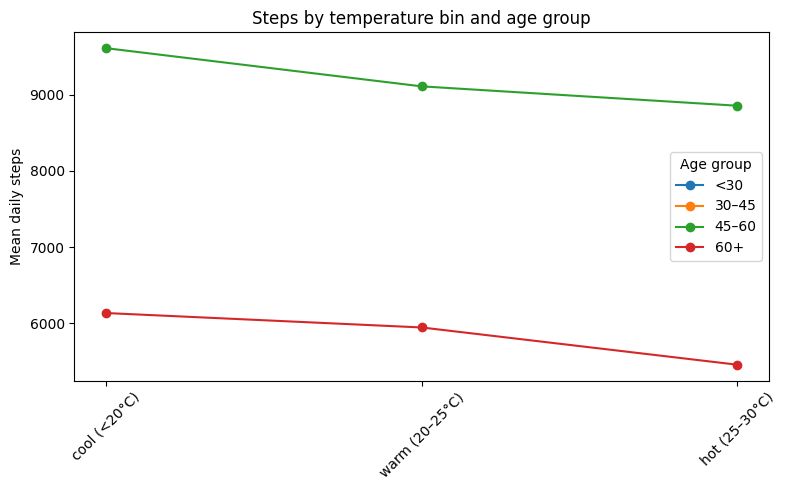

In [39]:
# Desired order of temperature bins
temp_order = ["cool (<20°C)", "warm (20–25°C)", "hot (25–30°C)"]

# Keep only the ones that exist, in that order
cols = [c for c in temp_order if c in steps_age_temp.columns]
steps_age_temp_ord = steps_age_temp[cols]

plt.figure(figsize=(8, 5))
for ag in steps_age_temp_ord.index:
    plt.plot(steps_age_temp_ord.columns,
             steps_age_temp_ord.loc[ag, :],
             marker="o",
             label=str(ag))
plt.xticks(rotation=45)
plt.ylabel("Mean daily steps")
plt.title("Steps by temperature bin and age group")
plt.legend(title="Age group")
plt.tight_layout()
plt.show()

In [40]:

if "is_hw_30C_3d" in panel_demo.columns:
    panel_demo["hw_flag"] = np.where(panel_demo["is_hw_30C_3d"], "heatwave", "non-heatwave")
    steps_gender_hw = (
        panel_demo
        .dropna(subset=["gender", "steps"])
        .groupby(["gender", "hw_flag"])["steps"]
        .agg(["count", "mean", "median"])
    )
    steps_gender_hw


## Outliers and robustness checks

In [41]:

rob = panel_demo.copy()
rob["steps"] = rob["steps"].fillna(0)
if "duration_min" in rob.columns:
    rob["duration_min"] = rob["duration_min"].fillna(0)

q99_steps = rob["steps"].quantile(0.99)
rob["is_steps_outlier"] = rob["steps"] > q99_steps

if "duration_min" in rob.columns:
    q99_dur = rob["duration_min"].quantile(0.99)
    rob["is_dur_outlier"] = rob["duration_min"] > q99_dur
else:
    rob["is_dur_outlier"] = False

rob[rob["is_steps_outlier"] | rob["is_dur_outlier"]].head()


,participant_id,date,steps,t_mean,temp_bin,is_hw_30C_3d,is_hw_q90_3d,is_hw_q95_2d,duration_min,gCO2,distance(m),weekday,month,gender,age,hw_flag_30C_3d,hw_flag_q90,age_group,hw_flag,is_steps_outlier,is_dur_outlier
19,0L3S1J,2025-05-26 00:00:00+00:00,15539.0,14.799091,cool (<20°C),False,False,False,536.150000,465.0,79427.0,0,5,NaN,NaN,non-heatwave,non-heatwave_q90,NaN,non-heatwave,False,True
27,0L3S1J,2025-06-03 00:00:00+00:00,23996.0,19.110099,cool (<20°C),False,False,False,308.883333,240177.0,1048629.0,1,6,NaN,NaN,non-heatwave,non-heatwave_q90,NaN,non-heatwave,True,False
28,0L3S1J,2025-06-04 00:00:00+00:00,10818.0,18.309005,cool (<20°C),False,False,False,2832.183333,0.0,5560.0,2,6,NaN,NaN,non-heatwave,non-heatwave_q90,NaN,non-heatwave,False,True
33,0L3S1J,2025-06-09 00:00:00+00:00,25137.0,17.468373,cool (<20°C),False,False,False,462.916667,1288.0,124278.0,0,6,NaN,NaN,non-heatwave,non-heatwave_q90,NaN,non-heatwave,True,False
46,0L3S1J,2025-06-22 00:00:00+00:00,21389.0,25.533243,hot (25–30°C),False,True,False,483.650000,22863.0,171108.0,6,6,NaN,NaN,non-heatwave,heatwave_q90,NaN,non-heatwave,False,True


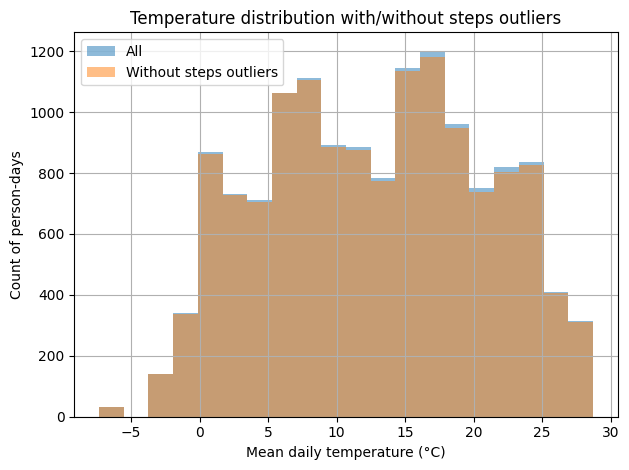

In [42]:

no_outliers = rob[~rob["is_steps_outlier"]].copy()

plt.figure()
rob["t_mean"].hist(alpha=0.5, bins=20)
no_outliers["t_mean"].hist(alpha=0.5, bins=20)
plt.xlabel("Mean daily temperature (°C)")
plt.ylabel("Count of person-days")
plt.title("Temperature distribution with/without steps outliers")
plt.legend(["All", "Without steps outliers"])
plt.tight_layout()
plt.show()
